In [1]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
                            confusion_matrix, 
                            f1_score,
                            accuracy_score,
                            precision_score,
                            recall_score
                            )
warnings.filterwarnings('ignore')

In [2]:
seed = 42
np.random.seed(seed)

### Quick Overview of Logistic Regression 

Y_hat(Z) = 1 / (1 + exp(-Z))

P(Y = 1 | X) = Y_hat(Z)

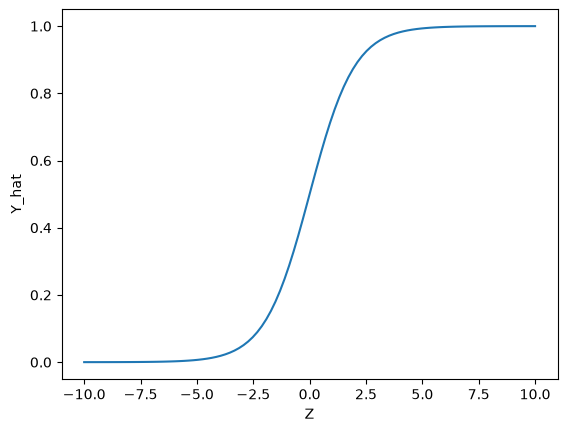

In [3]:
def sigmoid(Z):
    return 1 / (1 + np.exp(-Z))

X_linespace = np.linspace(-10, 10, 100)
Y_hat = sigmoid(X_linespace)

plt.plot(X_linespace, Y_hat)
plt.xlabel('Z')
plt.ylabel('Y_hat')
plt.show()

### Loading the Data 

In [4]:
from pathlib import Path

project_root = Path.cwd()
for parent in [project_root, *project_root.parents]:
    if (parent / 'artifacts').exists():
        project_root = parent
        break

with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_train.npz') as data:
    X_train = data['X_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_train.npz') as data:
    Y_train = data['y_train']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_X_test.npz') as data:
    X_test = data['X_test']
with np.load(project_root / 'artifacts' / 'credit_card_fraud_y_test.npz') as data:
    Y_test = data['y_test']

### Model Training 

In [5]:
model_lr = LogisticRegression(
                            random_state = 42,
                            max_iter = 1000      
                            )
model_lr.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

### Inference

Y_hat = Y_hat_proba > 0.5

In [6]:
Y_proba_train = model_lr.predict_proba(X_train)
Y_proba_test = model_lr.predict_proba(X_test)

In [7]:
pd.Series(Y_test).value_counts()

0    1970
1      30
Name: count, dtype: int64

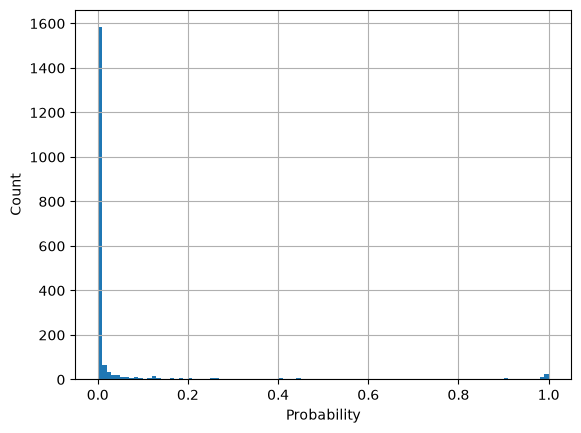

In [8]:
Y_lr_test =  Y_proba_test[:, 1]

plt.hist(Y_lr_test, bins=100)
plt.xlabel('Probability')
plt.ylabel('Count')
plt.grid(True)
plt.show()

### Evaluation

In [9]:
Y_hat_test = Y_lr_test > 0.65
Y_hat_test

array([False, False, False, ..., False, False, False], shape=(2000,))

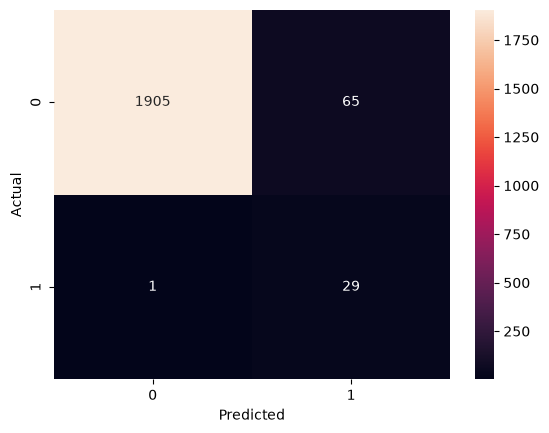

In [10]:
cm = confusion_matrix(Y_test, Y_hat_test)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 5. Multi-Model Threshold Optimization

Now let's expand the threshold optimization to all trained models, including the newly added XGBoost, to find their best decision thresholds and compare their optimal performances.

In [11]:
# Define models with best parameters found in hyperparameter tuning
best_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=20, criterion='entropy'),
    'Random Forest': RandomForestClassifier(random_state=42, max_depth=12, n_estimators=100, criterion='gini'),
    'XGBoost': XGBClassifier(random_state=42, max_depth=10, n_estimators=200, learning_rate=0.2, subsample=1.0)
}

# Fit all models
for name, model in best_models.items():
    print(f"Training {name}...")
    model.fit(X_train, Y_train)

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost...


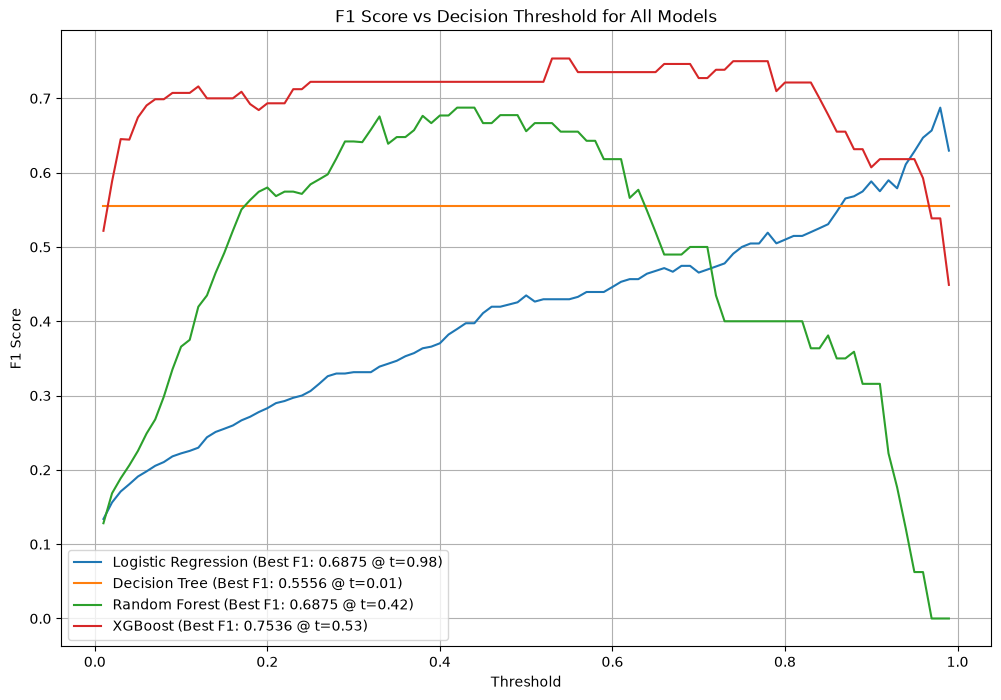

In [12]:
# Find optimal thresholds and plot F1 vs Threshold curves
thresholds = np.linspace(0.01, 0.99, 99)
optimal_thresholds = {}

plt.figure(figsize=(12, 8))

for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    f1_scores = []
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1_scores.append(f1_score(Y_test, y_pred))
    
    best_idx = np.argmax(f1_scores)
    best_t = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]
    optimal_thresholds[name] = (best_t, best_f1)
    
    # Plot F1 vs Threshold curve
    plt.plot(thresholds, f1_scores, label=f"{name} (Best F1: {best_f1:.4f} @ t={best_t:.2f})")

plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Decision Threshold for All Models')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# Display summary of default vs optimal threshold performance
summary_data = []
for name, model in best_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Default performance (threshold = 0.5)
    y_pred_default = (y_proba >= 0.5).astype(int)
    f1_default = f1_score(Y_test, y_pred_default)
    prec_default = precision_score(Y_test, y_pred_default)
    rec_default = recall_score(Y_test, y_pred_default)
    
    # Optimal performance
    opt_t, opt_f1 = optimal_thresholds[name]
    y_pred_opt = (y_proba >= opt_t).astype(int)
    f1_opt = f1_score(Y_test, y_pred_opt)
    prec_opt = precision_score(Y_test, y_pred_opt)
    rec_opt = recall_score(Y_test, y_pred_opt)
    
    summary_data.append({
        'Model': name,
        'Default Threshold': 0.5,
        'Default F1': f1_default,
        'Default Precision': prec_default,
        'Default Recall': rec_default,
        'Optimal Threshold': opt_t,
        'Optimal F1': f1_opt,
        'Optimal Precision': prec_opt,
        'Optimal Recall': rec_opt
    })

df_summary = pd.DataFrame(summary_data)
df_summary

,Model,Default Threshold,Default F1,Default Precision,Default Recall,Optimal Threshold,Optimal F1,Optimal Precision,Optimal Recall
0,Logistic Regression,0.5,0.434783,0.277778,1.000000,0.98,0.687500,0.647059,0.733333
1,Decision Tree,0.5,0.555556,0.476190,0.666667,0.01,0.555556,0.476190,0.666667
2,Random Forest,0.5,0.655738,0.645161,0.666667,0.42,0.687500,0.647059,0.733333
3,XGBoost,0.5,0.722222,0.619048,0.866667,0.53,0.753623,0.666667,0.866667


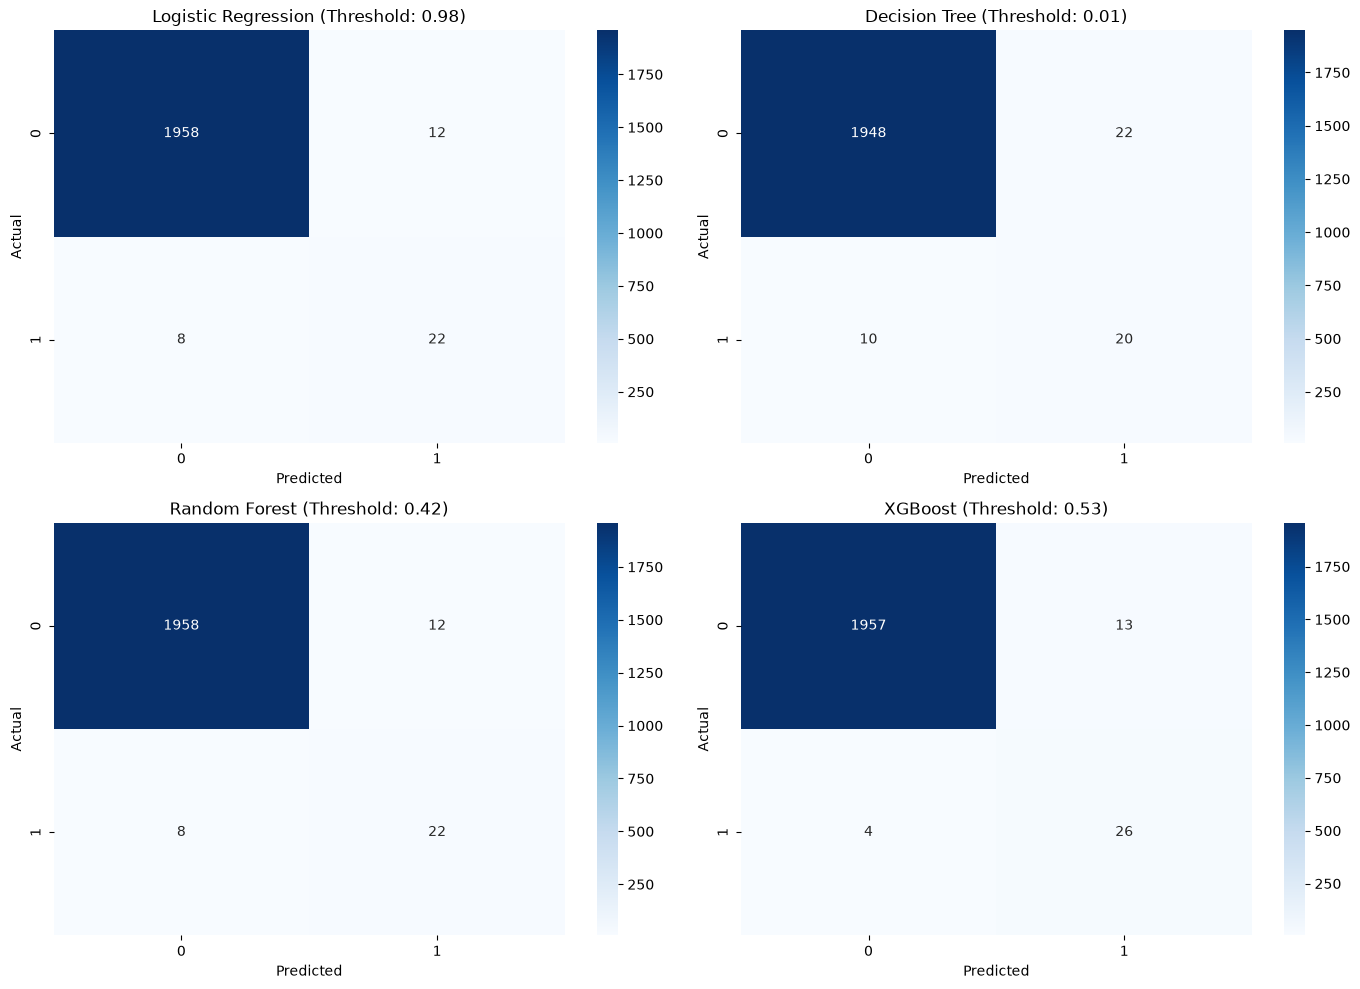

In [14]:
# Plot confusion matrices for all models under their optimal thresholds
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(best_models.items()):
    y_proba = model.predict_proba(X_test)[:, 1]
    opt_t, _ = optimal_thresholds[name]
    y_pred_opt = (y_proba >= opt_t).astype(int)
    
    cm = confusion_matrix(Y_test, y_pred_opt)
    sns.heatmap(cm, annot=True, fmt='d', ax=axes[idx], cmap='Blues')
    axes[idx].set_title(f"{name} (Threshold: {opt_t:.2f})")
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()